In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

#!{sys.executable} -m pip install -U plotly kaleido

/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:777: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':
/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:1029: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':
/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:1637: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':


In [ ]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for use_optimal_travel in [True, False]:
    for mouse, days in mouse_days.items():
        for day in days:
        
            gcs, ngs, all_cells = classify_cells_both_sessions(mouse, day, use_optimal_travel=use_optimal_travel, 
                                                               get_extra_info=True, disqualifying_regions=[])

            # add columns for all cells whether the use_optimal_travel is True or False
            for cells in [gcs, ngs, all_cells]:
                cells['use_optimal_travel'] = np.repeat(use_optimal_travel, len(cells))
                cells['mouse'] = np.repeat(mouse, len(cells))
                cells['day'] = np.repeat(day, len(cells))
              
            gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
            ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
            all_ = pd.concat([all_, all_cells], ignore_index=True)

        print(f'there are this many cells at the moment, {len(all_)}')


there are this many cells at the moment, 1438
there are this many cells at the moment, 4527
there are this many cells at the moment, 6475
there are this many cells at the moment, 7491
there are this many cells at the moment, 8630
there are this many cells at the moment, 9896
there are this many cells at the moment, 10891
there are this many cells at the moment, 12225
there are this many cells at the moment, 13663
there are this many cells at the moment, 16752
there are this many cells at the moment, 18700
there are this many cells at the moment, 19716
there are this many cells at the moment, 20855
there are this many cells at the moment, 22121
there are this many cells at the moment, 23116
there are this many cells at the moment, 24450


In [11]:
_key_cols = ['mouse', 'day', 'use_optimal_travel', 'cluster_id']
_gc_ngs_keys = pd.concat([gcs_[_key_cols], ngs_[_key_cols]]).drop_duplicates()
ns_ = all_.merge(_gc_ngs_keys, on=_key_cols, how='left', indicator=True)
ns_ = ns_[ns_['_merge'] == 'left_only'].drop(columns='_merge').reset_index(drop=True)
print(f'{len(ns_)} non-spatial cells  ({len(gcs_)} GC, {len(ngs_)} NGS, {len(all_)} total)')


6307 non-spatial cells  (1401 GC, 16742 NGS, 24450 total)


lets run a sanity check to see if there is any difference in the plot depending on how we are classifying the cells

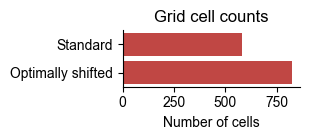

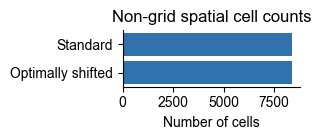

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Count cells for gcs_ and ngs_ separately
gcs_counts = gcs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)
ngs_counts = ngs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)

labels = ['Optimally shifted', 'Standard']

# Grid cells (GCS) horizontal bar plot
fig, ax = plt.subplots(figsize=(3.2, 1.5))
ax.barh(labels, gcs_counts.values, color=['#c04744', '#c04744'])
ax.set_title('Grid cell counts')
ax.set_xlabel('Number of cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/classified_GC.pdf', bbox_inches='tight')
plt.show()

# Non-grid spatial cells (NGS) horizontal bar plot
fig, ax = plt.subplots(figsize=(3.2, 1.5))
ax.barh(labels, ngs_counts.values, color=['#3171ae', '#3171ae'])
ax.set_title('Non-grid spatial cell counts')
ax.set_xlabel('Number of cells')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/classified_NGS.pdf', bbox_inches='tight')
plt.show()

We can see there is a clear difference in the number of classified grid cells when using the optimal travel lag or not, however this isn't the case for non-grid spatial cells. The spatial information score is thus sufficiently high at travel=0 to surpass the shuffled threshold. We can test the spatial information and grid scores measured at the optimal travel versus travel = 0

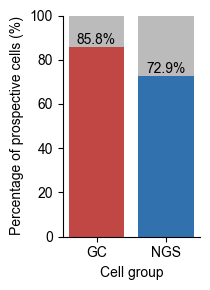

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()
gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]
gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Calculate proportions
prop_df = combined.groupby('group')['optimal_travel_lag'].apply(
    lambda x: pd.Series({
        'Predictive': (x > 0).sum(),
        'Non-predictive': (x <= 0).sum()
    })
).unstack()

prop_percent = prop_df.div(prop_df.sum(axis=1), axis=0) * 100

# Stacked bar plot with Predictive on bottom
fig, ax = plt.subplots(figsize=(2.2, 3))
bars_pred = ax.bar(
    prop_percent.index,
    prop_percent['Predictive'],
    color=['#c04744', '#3171ae'],
    label='Predictive'
)
bars_nonpred = ax.bar(
    prop_percent.index,
    prop_percent['Non-predictive'],
    bottom=prop_percent['Predictive'],
    color=['#bbbbbb', '#bbbbbb'],
    label='Non-predictive'
)

# Annotate percentage on top of Predictive group
for bar, pct in zip(bars_pred, prop_percent['Predictive']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylabel('Percentage of prospective cells (%)')
ax.set_xlabel('Cell group')
ax.set_ylim(0, 100)
ax.set_xticks(range(len(prop_percent.index)))
ax.set_xticklabels(prop_percent.index)
ax.legend().remove()  # Remove legend
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/prospective_cells_percentage.pdf', bbox_inches='tight')
plt.show()

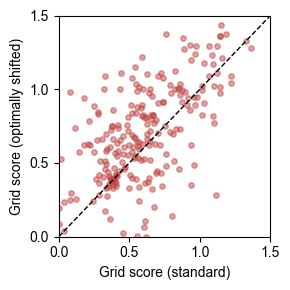

In [5]:
import matplotlib.pyplot as plt

# Filter for matching rows by mouse, day, and cluster_id
gcs_true = gcs_[gcs_['use_optimal_travel'] == True]
gcs_false = gcs_[gcs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    gcs_true[['mouse', 'day', 'cluster_id', 'grid_score']],
    gcs_false[['mouse', 'day', 'cluster_id', 'grid_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Scatter plot
plt.figure(figsize=(3, 3))
plt.xticks(np.arange(0,1.6,0.5))
plt.yticks(np.arange(0,1.6,0.5))
plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.scatter(paired['grid_score_false'], paired['grid_score_true'], color='#c04744', alpha=0.5, s=15)
plt.plot([0,1.5],[0,1.5],color='black', linestyle='--', linewidth=1)  # Unity line
plt.xlabel('Grid score (standard)')
plt.ylabel('Grid score (optimally shifted)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/grid_score_standard_vs_optimal_GC.pdf', bbox_inches='tight')
plt.show()

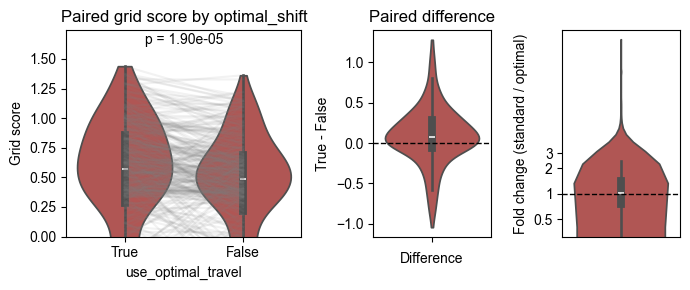

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Filter for matching rows by mouse, day, and cluster_id
gcs_true = gcs_[gcs_['use_optimal_travel'] == True]
gcs_false = gcs_[gcs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    gcs_true[['mouse', 'day', 'cluster_id', 'grid_score']],
    gcs_false[['mouse', 'day', 'cluster_id', 'grid_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Paired t-test
tstat, pval = ttest_rel(paired['grid_score_true'], paired['grid_score_false'])

# Prepare data for violin plot
plot_df = pd.DataFrame({
    'grid_score': pd.concat([paired['grid_score_true'], paired['grid_score_false']], ignore_index=True),
    'use_optimal_travel': ['True'] * len(paired) + ['False'] * len(paired)
})

# Prepare data for difference plot
diff = paired['grid_score_true'] - paired['grid_score_false']

# Prepare data for fold change plot
fold_change = paired['grid_score_true'] / paired['grid_score_false']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3), gridspec_kw={'width_ratios': [2, 1, 1]})

# Violin plot
sns.violinplot(data=plot_df, x='use_optimal_travel', y='grid_score', palette={'True': '#c04744', 'False': '#c04744'}, ax=ax1, inner='box', cut=0)
ax1.set_xlabel('use_optimal_travel')
ax1.set_ylabel('Grid score')
ax1.set_title('Paired grid score by optimal_shift')

# Draw lines connecting paired points
for i in range(len(paired)):
    ax1.plot(
        [0, 1],
        [paired.iloc[i]['grid_score_true'], paired.iloc[i]['grid_score_false']],
        color='gray',
        alpha=0.1
    )

# Place p-value above the highest flier
ymax = plot_df['grid_score'].max()
ymax += (ymax * 0.1)
ax1.set_ylim(0, ymax + (ymax * 0.1))
ax1.text(0.5, ymax + (ymax * 0.01), f'p = {pval:.2e}', ha='center', va='bottom', fontsize=10)

# Difference plot
sns.violinplot(y=diff, ax=ax2, color='#c04744', inner='box', cut=0)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Difference')
ax2.set_ylabel('True - False')
ax2.set_title('Paired difference')

# Fold change plot
sns.violinplot(y=fold_change, ax=ax3, color='#c04744', inner='box', cut=0)
ax3.axhline(1, color='black', linestyle='--', linewidth=1)
ax3.set_ylabel('Fold change (standard / optimal)')
ax3.set_xticks([])  # Hide x-ticks for fold change plot
ax3.set_yscale('log')
ax3.set_yticks([0.5, 1, 2,3])
ax3.set_yticklabels(['0.5', '1', '2', '3'])
ax3.minorticks_off() 
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/grid_score_change_standard_versus_optimal_GC.pdf', bbox_inches='tight')
plt.show()

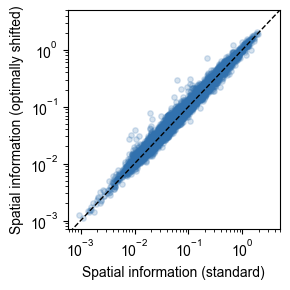

In [7]:
import matplotlib.pyplot as plt

# Filter for matching rows by mouse, day, and cluster_id
ngs_true = ngs_[ngs_['use_optimal_travel'] == True]
ngs_false = ngs_[ngs_['use_optimal_travel'] == False]

# Merge on mouse, day, cluster_id to get paired grid_scores
paired = pd.merge(
    ngs_true[['mouse', 'day', 'cluster_id', 'spatial_information_score']],
    ngs_false[['mouse', 'day', 'cluster_id', 'spatial_information_score']],
    on=['mouse', 'day', 'cluster_id'],
    suffixes=('_true', '_false')
).dropna()

# Scatter plot
plt.figure(figsize=(3, 3))
plt.scatter(paired['spatial_information_score_false'], paired['spatial_information_score_true'], color='#3171ae', alpha=0.2, s=15)
plt.plot([0,10],[0,10],color='black', linestyle='--', linewidth=1)  # Unity line
# set x and y to logathmic scale
plt.xscale('log')
plt.yscale('log')
plt.xlim(None, 5)
plt.ylim(None, 5)
plt.xlabel('Spatial information (standard)')
plt.ylabel('Spatial information (optimally shifted)')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_information_standard_vs_optimal_NGS.pdf', bbox_inches='tight')
plt.show()

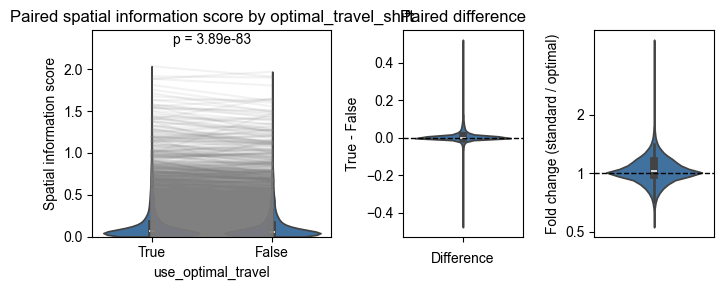

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Paired t-test
tstat, pval = ttest_rel(paired['spatial_information_score_true'], paired['spatial_information_score_false'])

# Prepare data for violin plot
plot_df = pd.DataFrame({
    'spatial_information_score': pd.concat([paired['spatial_information_score_true'], paired['spatial_information_score_false']], ignore_index=True),
    'use_optimal_travel': ['True'] * len(paired) + ['False'] * len(paired)
})

# Prepare data for difference plot
diff = paired['spatial_information_score_true'] - paired['spatial_information_score_false']

# Prepare data for fold change plot
fold_change = paired['spatial_information_score_true'] / paired['spatial_information_score_false']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7, 3), gridspec_kw={'width_ratios': [2, 1, 1]})

# Violin plot
sns.violinplot(data=plot_df, x='use_optimal_travel', y='spatial_information_score', palette={'True': '#3171ae', 'False': '#3171ae'}, ax=ax1, inner='box', cut=0)
ax1.set_xlabel('use_optimal_travel')
ax1.set_ylabel('Spatial information score')
ax1.set_title('Paired spatial information score by optimal_travel_shift')

# Draw lines connecting paired points
for i in range(len(paired)):
    ax1.plot(
        [0, 1],
        [paired.iloc[i]['spatial_information_score_true'], paired.iloc[i]['spatial_information_score_false']],
        color='gray',
        alpha=0.1
    )

# Place p-value above the highest flier
ymax = plot_df['spatial_information_score'].max()
ymax += (ymax * 0.1)
ax1.set_ylim(0, ymax + (ymax * 0.1))
ax1.text(0.5, ymax + (ymax * 0.01), f'p = {pval:.2e}', ha='center', va='bottom', fontsize=10)

# Difference plot
sns.violinplot(y=diff, ax=ax2, color='#3171ae', inner='box', cut=0)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Difference')
ax2.set_ylabel('True - False')
ax2.set_title('Paired difference')

# Fold change plot
sns.violinplot(y=fold_change, ax=ax3, color='#3171ae', inner='box', cut=0)
ax3.axhline(1, color='black', linestyle='--', linewidth=1)
ax3.set_ylabel('Fold change (standard / optimal)')
ax3.set_yscale('log')
ax3.set_xticks([])  # Hide x-ticks for fold change plot
ax3.set_yticks([0.5, 1, 2])
ax3.set_yticklabels(['0.5', '1', '2'])
ax3.minorticks_off() 
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/spatial_information_change_standard_versus_optimal_NGS.pdf', bbox_inches='tight')
plt.show()

In [9]:
def add_percentile(data, score_column, shuffle_column):
    """Calculate the percentile rank of a value within a dataset."""
    score_percentiles = []
    for index, row in data.iterrows():
        score = row[score_column]
        shuffle_values = np.array(row[shuffle_column])
        percentile = (np.nansum(shuffle_values < score) / len(shuffle_values)) * 100
        #print(f'Index: {index}, Score: {score}, Percentile: {percentile}')
        if np.isnan(percentile):
            print(f'Warning: Percentile is NaN for index {index}')
        score_percentiles.append(percentile)
    data[f'{score_column}_percentile'] = score_percentiles
    return data

In [12]:
# for gcs_, ngs_, and ns_, calculate the percentile of each cell grid_score, spatial_information_score, 
# and spatial_information_score respectively against the distrubution of scores for each cell 

grids_using_standard = gcs_[gcs_['use_optimal_travel'] == False]
grids_using_standard['cell_classification'] = 'sGC'
non_grids_using_standard = ngs_[ngs_['use_optimal_travel'] == False]
non_grids_using_standard['cell_classification'] = 'sNGS'
non_spatial_using_standard = ns_[ns_['use_optimal_travel'] == False]
non_spatial_using_standard['cell_classification'] = 'sNS'
all_using_standard = pd.concat([grids_using_standard, non_grids_using_standard, non_spatial_using_standard], ignore_index=True)

grids_using_optimal = gcs_[gcs_['use_optimal_travel'] == True]
grids_using_optimal['cell_classification'] = 'oGC'
non_grids_using_optimal = ngs_[ngs_['use_optimal_travel'] == True]
non_grids_using_optimal['cell_classification'] = 'oNGS'
non_spatial_using_optimal = ns_[ns_['use_optimal_travel'] == True]
non_spatial_using_optimal['cell_classification'] = 'oNS'
all_using_optimal = pd.concat([grids_using_optimal, non_grids_using_optimal, non_spatial_using_optimal], ignore_index=True)
print(f'There are {len(all_using_standard)} cells using standard travel lag, and {len(all_using_optimal)} cells using optimal travel lag')

# add percenitle columns for grid_score and spatial_information_score
all_using_standard = add_percentile(all_using_standard, 'grid_score', 'grid_shuffles_scores')
all_using_standard = add_percentile(all_using_standard, 'spatial_information_score', 'spatial_information_shuffles_scores')
all_using_optimal = add_percentile(all_using_optimal, 'grid_score', 'grid_shuffles_scores')
all_using_optimal = add_percentile(all_using_optimal, 'spatial_information_score', 'spatial_information_shuffles_scores')

# combined cluster_id mouse day into a single identifier
all_using_standard['unique_id'] = all_using_standard.apply(lambda row: f"{row['mouse']}_{row['day']}_{row['cluster_id']}", axis=1)
all_using_optimal['unique_id'] = all_using_optimal.apply(lambda row: f"{row['mouse']}_{row['day']}_{row['cluster_id']}", axis=1)


There are 12225 cells using standard travel lag, and 12225 cells using optimal travel lag


In [13]:
import pandas as pd
import plotly.graph_objects as go

# Color map for left nodes (standard)
color_map_left = {
    'sGC': '#c04744',   # GC color
    'sNGS': '#3171ae',  # NGS color
    'sNS': '#bbbbbb'    # NS color (gray)
}
# Color map for right nodes (optimal)
color_map_right = {
    'oGC': '#c04744',
    'oNGS': '#3171ae',
    'oNS': '#bbbbbb'
}

# Ensure unique_id exists in both DataFrames
if 'unique_id' not in all_using_standard.columns:
    all_using_standard['unique_id'] = all_using_standard.apply(lambda row: f"{row['mouse']}_{row['day']}_{row['cluster_id']}", axis=1)
if 'unique_id' not in all_using_optimal.columns:
    all_using_optimal['unique_id'] = all_using_optimal.apply(lambda row: f"{row['mouse']}_{row['day']}_{row['cluster_id']}", axis=1)

# Merge to get transitions for cells present in both
merged = pd.merge(
    all_using_standard[['unique_id', 'cell_classification']],
    all_using_optimal[['unique_id', 'cell_classification']],
    on='unique_id',
    suffixes=('_standard', '_optimal')
)

# Define node labels
left_nodes = ['sGC', 'sNGS', 'sNS']
right_nodes = ['oGC', 'oNGS', 'oNS']
labels = left_nodes + right_nodes

# Assign node colors in order
node_colors = [color_map_left[n] for n in left_nodes] + [color_map_right[n] for n in right_nodes]

# Map node names to indices
left_map = {name: i for i, name in enumerate(left_nodes)}
right_map = {name: i + len(left_nodes) for i, name in enumerate(right_nodes)}

# Count transitions
transitions = merged.groupby(['cell_classification_standard', 'cell_classification_optimal']).size().reset_index(name='count')

# Build source, target, value lists
sources = transitions['cell_classification_standard'].map(left_map)
targets = transitions['cell_classification_optimal'].map(right_map)
values = transitions['count']

# Optional: color links by source node color
link_colors = [color_map_left[src] for src in transitions['cell_classification_standard']]

# Add node counts to labels
left_counts = merged['cell_classification_standard'].value_counts().reindex(left_nodes, fill_value=0)
right_counts = merged['cell_classification_optimal'].value_counts().reindex(right_nodes, fill_value=0)
labels_with_counts = [f"{n}\n({left_counts[n]})" for n in left_nodes] + [f"{n}\n({right_counts[n]})" for n in right_nodes]

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(label=labels_with_counts, pad=20, thickness=20, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors)
))
fig.show()
fig.write_image("/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/standard_to_optimal_shifting_sankey.pdf")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import tempfile, os
import plotly.graph_objects as go

# ── Re-render the Sankey to a high-res temp PNG ───────────────────────────────
sankey_fig = go.Figure(go.Sankey(
    node=dict(label=labels_with_counts, pad=20, thickness=20, color=node_colors),
    link=dict(source=sources, target=targets, value=values, color=link_colors)
))
_sankey_tmp = tempfile.mktemp(suffix='.png')
sankey_fig.write_image(_sankey_tmp, width=1800, height=1200, scale=3)

# ── Cell count data ───────────────────────────────────────────────────────────
gcs_counts = gcs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)
ngs_counts = ngs_['use_optimal_travel'].value_counts().reindex([True, False], fill_value=0)
bar_labels = ['Optimally\nshifted', 'Standard']

# ── Combined figure: 1 row × 2 columns ───────────────────────────────────────
fig = plt.figure(figsize=(12, 5))
outer_gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3, width_ratios=[1.5, 2.5])

# Left column: 2 rows for GC and NGS bar charts
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, 0], hspace=0.65)
ax_gc  = fig.add_subplot(inner_gs[0])
ax_ngs = fig.add_subplot(inner_gs[1])

ax_gc.barh(bar_labels, gcs_counts.values, color='#c04744')
ax_gc.set_title('Grid cell counts', fontsize=9)
ax_gc.set_xlabel('Number of cells', fontsize=8)
ax_gc.spines['top'].set_visible(False)
ax_gc.spines['right'].set_visible(False)

ax_ngs.barh(bar_labels, ngs_counts.values, color='#3171ae')
ax_ngs.set_title('Non-grid spatial cell counts', fontsize=9)
ax_ngs.set_xlabel('Number of cells', fontsize=8)
ax_ngs.spines['top'].set_visible(False)
ax_ngs.spines['right'].set_visible(False)

# Right column: Sankey embedded as image, filling the axes
ax_sankey = fig.add_subplot(outer_gs[0, 1])
sankey_img = mpimg.imread(_sankey_tmp)
ax_sankey.imshow(sankey_img, aspect='auto', interpolation='antialiased')
ax_sankey.axis('off')
os.remove(_sankey_tmp)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/cell_counts_and_sankey.pdf', bbox_inches='tight', dpi=300)
plt.show()


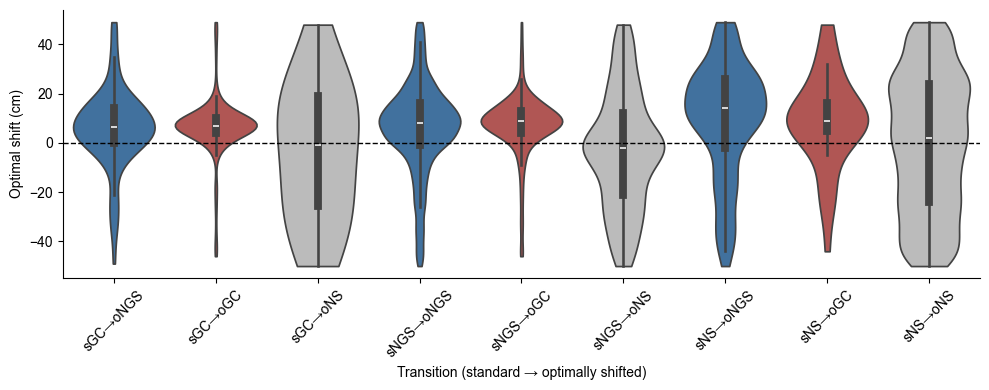

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge to get transitions for cells present in both, and bring in optimal_travel_lag from all_using_optimal
merged = pd.merge(
    all_using_standard[['unique_id', 'cell_classification']],
    all_using_optimal[['unique_id', 'cell_classification', 'optimal_travel_lag']],
    on='unique_id',
    suffixes=('_standard', '_optimal')
)

# Only keep sGC, sNGS, sNS as standard, and oGC, oNGS, oNS as optimal
s_classes = ['sGC', 'sNGS', 'sNS']
o_classes = ['oGC', 'oNGS', 'oNS']
merged = merged[merged['cell_classification_standard'].isin(s_classes) & merged['cell_classification_optimal'].isin(o_classes)]

# For each (s_class, o_class) pair, plot violin of optimal_travel_lag
merged['transition'] = merged['cell_classification_standard'] + '→' + merged['cell_classification_optimal']

# Desired order
order = [
    'sGC→oNGS', 'sGC→oGC', 'sGC→oNS',
    'sNGS→oNGS', 'sNGS→oGC', 'sNGS→oNS',
    'sNS→oNGS', 'sNS→oGC', 'sNS→oNS'
]

# Set color palette based on o group (optimal classification)
o_color_map = {
    'oGC': '#c04744',
    'oNGS': '#3171ae',
    'oNS': '#bbbbbb'
}
palette = {transition: o_color_map[transition.split('→')[1]] for transition in order}

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(
    data=merged,
    x='transition',
    y='optimal_travel_lag',
    order=order,
    palette=palette,
    cut=0,
    inner='box',
    ax=ax
)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Optimal shift (cm)')
ax.set_xlabel('Transition (standard → optimally shifted)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_travel_lag_by_cell_classification_transition.pdf', bbox_inches='tight')
plt.show()


Summary for GC vs zero:
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: optimal_travel_lag
No. Observations: 822     Method:             REML              
No. Groups:       8       Scale:              142.4295          
Min. group size:  39      Log-Likelihood:     -3244.5371        
Max. group size:  196     Converged:          Yes               
Mean group size:  102.8                                         
------------------------------------------------------------------
               Coef.    Std.Err.     z     P>|z|   [0.025   0.975]
------------------------------------------------------------------
Intercept       6.051      0.875   6.913   0.000    4.335    7.766
cluster Var     0.000      1.997                                  
day Var        34.636      1.026                                  


Explanation: This model tests whether the mean optimal_travel_lag for GC cells is significantly different from zero, accounting f

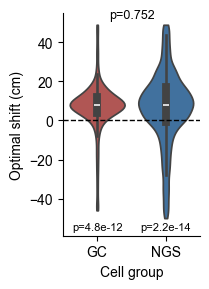

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()
gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine data
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)
combined = combined[combined['use_optimal_travel'] == True]

# Ensure cluster_id and day are strings
combined['cluster_id'] = combined['cluster_id'].astype(str)
combined['day'] = combined['day'].astype(str)

# Variance components for hierarchical random effects
vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# Mixed model for each group vs zero
pvals_vs_zero = []
for grp in ['GC', 'NGS']:
    df_grp = combined[combined['group'] == grp].dropna(subset=['optimal_travel_lag'])
    if len(df_grp) < 5:
        pvals_vs_zero.append(np.nan)
        continue
    try:
        model = smf.mixedlm(
            "optimal_travel_lag ~ 1",
            df_grp,
            groups=df_grp["mouse"],
            vc_formula=vc
        )
        result = model.fit()
        print(f"\nSummary for {grp} vs zero:\n", result.summary())
        print(f"\nExplanation: This model tests whether the mean optimal_travel_lag for {grp} cells is significantly different from zero, accounting for random effects of mouse, day, and cluster_id.")
        pval = result.pvalues['Intercept']
        pvals_vs_zero.append(pval)
    except Exception as e:
        print(f"\n{grp} model failed: {e}")
        pvals_vs_zero.append(np.nan)

# Mixed model for group comparison
try:
    model_comp = smf.mixedlm(
        "optimal_travel_lag ~ group",
        combined,
        groups=combined["mouse"],
        vc_formula=vc
    )
    result_comp = model_comp.fit()
    print("\nSummary for group comparison (GC vs NGS):\n", result_comp.summary())
    print("\nExplanation: This model tests whether there is a significant difference in optimal_travel_lag between GC and NGS cells, controlling for mouse, day, and cluster_id as random effects.")
    pval_group = result_comp.pvalues.get('group[T.NGS]', np.nan)
except Exception as e:
    print(f"\nGroup comparison model failed: {e}")
    pval_group = np.nan

# Create violin plot
fig, ax = plt.subplots(figsize=(2.2, 3))
sns.violinplot(
    data=combined,
    x='group',
    y='optimal_travel_lag',
    palette={'GC': '#c04744', 'NGS': '#3171ae'},
    cut=0,
    inner='box',
    ax=ax
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Optimal shift (cm)')
ax.set_xlabel('Cell group')
ax.set_ylim(-50, 50)

# Annotate p-values below each violin (comparison vs zero)
for i, pval in enumerate(pvals_vs_zero):
    if np.isnan(pval):
        label = "n/a"
    elif pval < 0.001:
        label = f"p={pval:.1e}"
    else:
        label = f"p={pval:.3f}"
    ax.text(i, -57, label, ha='center', va='bottom', fontsize=8, color='black')

# Annotate p-value for group comparison above violins
if np.isnan(pval_group):
    label = "n/a"
elif pval_group < 0.001:
    label = f"p={pval_group:.1e}"
else:
    label = f"p={pval_group:.3f}"
ax.text(0.5, 57, f"{label}", ha='center', va='top', fontsize=9, color='black')
ax.set_ylim(-59, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_spatial_information_lag_by_cell_type_violin.pdf', bbox_inches='tight')
plt.show()

In [16]:
def add_optimal_shift(df):
    # Find the index of the max score and get the corresponding travel value for each row
    df['optimal_shift_based_on_spatial_information'] = [
        row['spatial_information_travel'][np.argmax(row['spatial_information_travel_scores'])]
        if isinstance(row['spatial_information_travel_scores'], (list, np.ndarray)) and len(row['spatial_information_travel_scores']) > 0
        else np.nan
        for _, row in df.iterrows()
    ]
    return df

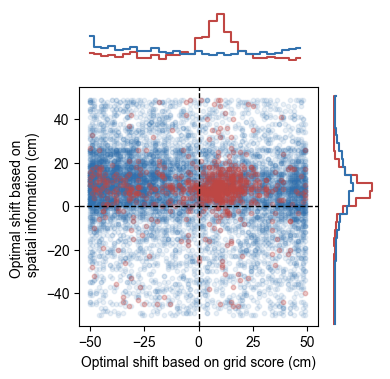

In [17]:
import matplotlib.pyplot as plt
import numpy as np

gcs_df_copy = gcs_df[gcs_df['use_optimal_travel'] == True].copy()
ngs_df_copy = ngs_df[ngs_df['use_optimal_travel'] == True].copy()
gcs_df_copy = add_optimal_shift(gcs_df_copy)
ngs_df_copy = add_optimal_shift(ngs_df_copy)

fig, axes = plt.subplots(2, 2, figsize=(4, 4), width_ratios=[1, 0.2], height_ratios=[0.2,1])
ax_scatter = axes[1, 0]
ax_density_x = axes[0, 0]
ax_density_y = axes[1, 1]
axes[0, 1].axis('off')  # Top right blank
axes[1, 1].axis('off')  # Bottom right blank
axes[0, 0].axis('off')  # Top left blank

# Scatter plot (bottom left)
ax_scatter.scatter(
    ngs_df_copy['optimal_travel_lag_grid_score'], ngs_df_copy['optimal_shift_based_on_spatial_information'],
    color='#3171ae', alpha=0.1, label='NGS', s=10
)
ax_scatter.scatter(
    gcs_df_copy['optimal_travel_lag_grid_score'], gcs_df_copy['optimal_shift_based_on_spatial_information'],
    color='#c04744', alpha=0.3, label='GCS', s=10
)
ax_scatter.set_xlabel('Optimal shift based on grid score (cm)')
ax_scatter.set_ylabel('Optimal shift based on \n spatial information (cm)')
ax_scatter.set_xlim(-55, 55)
ax_scatter.set_ylim(-55, 55)
ax_scatter.set_aspect('equal', adjustable='box')
ax_scatter.grid(False)
ax_scatter.axhline(0, color='black', linestyle='--', linewidth=1)
ax_scatter.axvline(0, color='black', linestyle='--', linewidth=1)

# Top left: Histogram for x (optimal_travel_lag_grid_score)
bins = np.linspace(-50, 50, 31)
gcs_hist, _ = np.histogram(gcs_df_copy['optimal_travel_lag_grid_score'], bins=bins, density=True)
ngs_hist, _ = np.histogram(ngs_df_copy['optimal_travel_lag_grid_score'], bins=bins, density=True)
ax_density_x.step(bins[:-1], gcs_hist, where='mid', color='#c04744', label='GCS')
ax_density_x.step(bins[:-1], ngs_hist, where='mid', color='#3171ae', label='NGS')
ax_density_x.set_ylabel('Density')
ax_density_x.set_xlabel('')
ax_density_x.grid(False)
ax_density_x.set_ylim(0, max(gcs_hist.max(), ngs_hist.max()) * 1.1  )
ax_density_x.set_xlim(-55, 55)


# Bottom right: Histogram for y (optimal_shift_based_on_spatial_information), horizontal
bins_y = np.linspace(-50, 50, 31)
gcs_hist_y, _ = np.histogram(gcs_df_copy['optimal_shift_based_on_spatial_information'], bins=bins_y, density=True)
ngs_hist_y, _ = np.histogram(ngs_df_copy['optimal_shift_based_on_spatial_information'], bins=bins_y, density=True)
ax_density_y.step(gcs_hist_y, bins_y[:-1], where='mid', color='#c04744', label='GCS')
ax_density_y.step(ngs_hist_y, bins_y[:-1], where='mid', color='#3171ae', label='NGS')
ax_density_y.set_xlabel('Density')
ax_density_y.set_ylabel('')
ax_density_y.grid(False)
ax_density_y.set_ylim(-55, 55)
ax_density_y.set_xlim(0, max(gcs_hist_y.max(), ngs_hist_y.max()) * 1.1  )

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_shift_grid_score_vs_spatial_information.pdf', bbox_inches='tight')
plt.show()

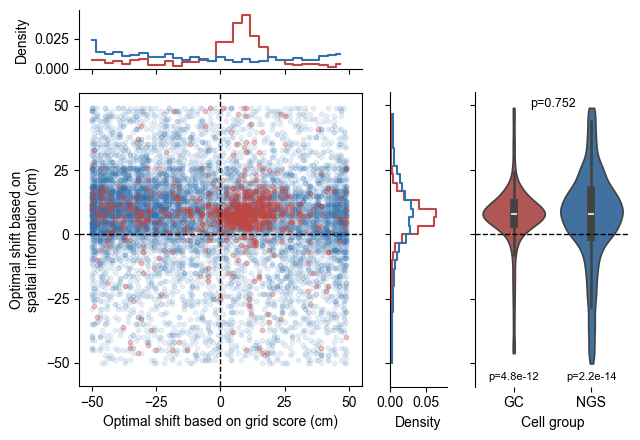

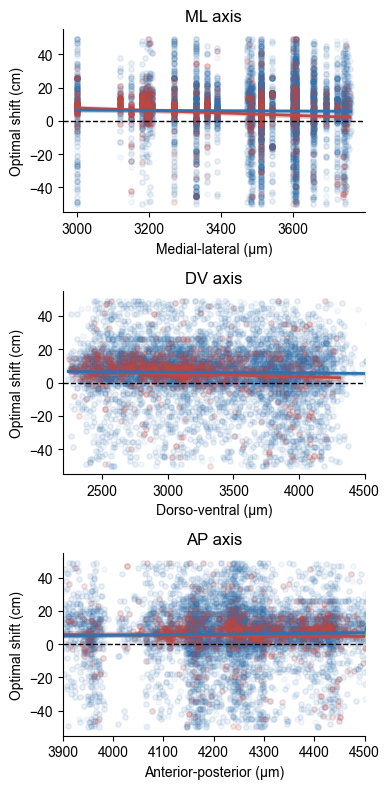

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

# ── Prepare scatter/histogram data ───────────────────────────────────────────
gcs_df_copy2 = gcs_df[gcs_df['use_optimal_travel'] == True].copy()
ngs_df_copy2 = ngs_df[ngs_df['use_optimal_travel'] == True].copy()
gcs_df_copy2 = add_optimal_shift(gcs_df_copy2)
ngs_df_copy2 = add_optimal_shift(ngs_df_copy2)

# ── Prepare violin data + mixed models ───────────────────────────────────────
gcs_df_copy2['group'] = 'GC'
ngs_df_copy2['group'] = 'NGS'
combined2 = pd.concat([gcs_df_copy2, ngs_df_copy2], ignore_index=True)
combined2['cluster_id'] = combined2['cluster_id'].astype(str)
combined2['day']        = combined2['day'].astype(str)

vc = {"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"}

pvals_vs_zero = []
for grp in ['GC', 'NGS']:
    df_grp = combined2[combined2['group'] == grp].dropna(subset=['optimal_travel_lag'])
    if len(df_grp) < 5:
        pvals_vs_zero.append(np.nan)
        continue
    try:
        result = smf.mixedlm("optimal_travel_lag ~ 1", df_grp,
                             groups=df_grp["mouse"], vc_formula=vc).fit()
        pvals_vs_zero.append(result.pvalues['Intercept'])
    except Exception as e:
        print(f"{grp} vs zero LMM failed: {e}")
        pvals_vs_zero.append(np.nan)

try:
    result_comp2 = smf.mixedlm("optimal_travel_lag ~ group", combined2,
                                groups=combined2["mouse"], vc_formula=vc).fit()
    pval_group2 = result_comp2.pvalues.get('group[T.NGS]', np.nan)
except Exception as e:
    print(f"Group comparison LMM failed: {e}")
    pval_group2 = np.nan

# ── Anatomical axis LMMs ─────────────────────────────────────────────────────
gcs_ent = gcs_df[gcs_df['brain_region'].str.contains('ENT')].copy()
ngs_ent = ngs_df[ngs_df['brain_region'].str.contains('ENT')].copy()
gcs_ent['group'] = 'GC'
ngs_ent['group'] = 'NGS'
df_anat = pd.concat([gcs_ent, ngs_ent], ignore_index=True)
df_anat['cluster_id'] = df_anat['cluster_id'].astype(str)
df_anat['day']        = df_anat['day'].astype(str)
df_anat['mouse']      = df_anat['mouse'].astype(str)

def _fit_axis_lmm(df, coord_col, offset_name):
    d = df.dropna(subset=[coord_col]).copy()
    d[offset_name] = d[coord_col] - d[coord_col].min()
    formula = f"optimal_travel_lag ~ group * {offset_name}"
    try:
        result = smf.mixedlm(formula, d, groups=d["mouse"], vc_formula=vc).fit()
    except Exception as e:
        print(f"{offset_name} LMM failed: {e}")
        result = None
    return d, result

ml_df, result_ml = _fit_axis_lmm(df_anat.assign(**{'ml_abs': lambda d: d['SC_x'].abs()}),
                                  'ml_abs', 'ml_offset')
dv_df, result_dv = _fit_axis_lmm(df_anat, 'SC_y', 'dv_offset')
ap_df, result_ap = _fit_axis_lmm(df_anat, 'SC_z', 'ap_offset')

def _pred_and_se_gc(result, offset_name, x_offset):
    cov = result.cov_params()
    pred = result.params['Intercept'] + result.params[offset_name] * x_offset
    se   = np.sqrt(
        cov.loc['Intercept', 'Intercept'] +
        x_offset**2 * cov.loc[offset_name, offset_name] +
        2 * x_offset * cov.loc['Intercept', offset_name]
    )
    return pred, se

def _pred_and_se_ngs(result, offset_name, x_offset):
    cov     = result.cov_params()
    ngs_int = result.params.get('group[T.NGS]', 0)
    ngs_sl  = result.params.get(f'group[T.NGS]:{offset_name}', 0)
    pred = (result.params['Intercept'] + ngs_int
            + (result.params[offset_name] + ngs_sl) * x_offset)

    def _safe(key): return cov.loc[key, key] if key in cov.index else 0.0
    def _safe2(k1, k2): return cov.loc[k1, k2] if (k1 in cov.index and k2 in cov.index) else 0.0

    inter_key = f'group[T.NGS]:{offset_name}'
    slope_var = (_safe(offset_name) + _safe(inter_key)
                 + 2 * _safe2(offset_name, inter_key))
    cross     = (_safe2('Intercept', offset_name) + _safe2('group[T.NGS]', offset_name)
                 + _safe2('Intercept', inter_key) + _safe2('group[T.NGS]', inter_key))
    se = np.sqrt(
        _safe('Intercept') + _safe('group[T.NGS]') + 2 * _safe2('Intercept', 'group[T.NGS]')
        + x_offset**2 * slope_var
        + 2 * x_offset * cross
    )
    return pred, se

def _draw_axis_panel(ax, gc_df, ngs_df, result, coord_raw_col, offset_name,
                     xlabel, title, xlim=None):
    if result is None:
        ax.set_title(f'{title} (LMM failed)')
        return
    gc  = gc_df[gc_df['group'] == 'GC']
    ngs = ngs_df[ngs_df['group'] == 'NGS'] if 'group' in ngs_df.columns else ngs_df

    ax.scatter(ngs[coord_raw_col], ngs['optimal_travel_lag'],
               color='#3171ae', alpha=0.05, s=15, label='NGS')
    ax.scatter(gc[coord_raw_col],  gc['optimal_travel_lag'],
               color='#c04744',  alpha=0.15, s=15, label='GC')
    ax.set_yticks([-50, -25, 0, 25, 50])
    
    for grp_df, color, pred_fn in [
        (gc,  '#c04744', _pred_and_se_gc),
        (ngs, '#3171ae', _pred_and_se_ngs),
    ]:
        x_raw = np.linspace(grp_df[coord_raw_col].min(), grp_df[coord_raw_col].max(), 100)
        x_off = x_raw - grp_df[coord_raw_col].min()
        pred, se = pred_fn(result, offset_name, x_off)
        ax.plot(x_raw, pred, color=color, linewidth=2)
        ax.fill_between(x_raw, pred - se, pred + se, color=color, alpha=0.2)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Optimal shift (cm)')
    ax.set_title(title)
    ax.set_ylim(-55, 55)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if xlim:
        ax.set_xlim(*xlim)

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 1: scatter + marginals + violin (rows 0–1)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(
    2, 3,
    figsize=(6.5, 4.5),
    width_ratios=[1, 0.2, 0.55],
    height_ratios=[0.2, 1],
    sharey='row', sharex='col'
)

ax_scatter   = axes1[1, 0]
ax_density_x = axes1[0, 0]
ax_density_y = axes1[1, 1]
ax_violin    = axes1[1, 2]

axes1[0, 1].axis('off')
axes1[0, 2].axis('off')

# x-density histogram
bins = np.linspace(-50, 50, 31)
gcs_hist, _ = np.histogram(gcs_df_copy2['optimal_travel_lag_grid_score'], bins=bins, density=True)
ngs_hist, _ = np.histogram(ngs_df_copy2['optimal_travel_lag_grid_score'], bins=bins, density=True)
ax_density_x.step(bins[:-1], gcs_hist, where='mid', color='#c04744')
ax_density_x.step(bins[:-1], ngs_hist, where='mid', color='#3171ae')
ax_density_x.set_xlim(-55, 55)
ax_density_x.set_ylim(0, max(gcs_hist.max(), ngs_hist.max()) * 1.1)
ax_density_x.set_ylabel('Density'); ax_density_x.grid(False)
ax_density_x.spines['top'].set_visible(False)
ax_density_x.spines['right'].set_visible(False)

# scatter
ax_scatter.scatter(ngs_df_copy2['optimal_travel_lag_grid_score'],
                   ngs_df_copy2['optimal_shift_based_on_spatial_information'],
                   color='#3171ae', alpha=0.1, s=10, label='NGS')
ax_scatter.scatter(gcs_df_copy2['optimal_travel_lag_grid_score'],
                   gcs_df_copy2['optimal_shift_based_on_spatial_information'],
                   color='#c04744', alpha=0.3, s=10, label='GCS')
ax_scatter.set_xlabel('Optimal shift based on grid score (cm)')
ax_scatter.set_ylabel('Optimal shift based on\nspatial information (cm)')
ax_scatter.set_xlim(-55, 55); ax_scatter.set_ylim(-55, 55)
ax_scatter.set_aspect('equal', adjustable='box')
ax_scatter.grid(False)
ax_scatter.axhline(0, color='black', linestyle='--', linewidth=1)
ax_scatter.axvline(0, color='black', linestyle='--', linewidth=1)
ax_scatter.set_yticks([-50, -25, 0, 25, 50])
ax_scatter.set_xticks([-50, -25, 0, 25, 50])

# y-density histogram (turned off as marginal)
bins_y = np.linspace(-50, 50, 31)
gcs_hist_y, _ = np.histogram(gcs_df_copy2['optimal_shift_based_on_spatial_information'], bins=bins_y, density=True)
ngs_hist_y, _ = np.histogram(ngs_df_copy2['optimal_shift_based_on_spatial_information'], bins=bins_y, density=True)
ax_density_y.step(gcs_hist_y, bins_y[:-1], where='mid', color='#c04744')
ax_density_y.step(ngs_hist_y, bins_y[:-1], where='mid', color='#3171ae')
ax_density_y.set_ylim(-55, 55)
ax_density_y.set_xlim(0, max(gcs_hist_y.max(), ngs_hist_y.max()) * 1.1)
ax_density_y.set_xlabel('Density'); ax_density_y.grid(False)
ax_density_y.spines['top'].set_visible(False)
ax_density_y.spines['right'].set_visible(False)
ax_density_y.set_yticks([-50, -25, 0, 25, 50])

# violin
sns.violinplot(data=combined2, x='group', y='optimal_travel_lag',
               palette={'GC': '#c04744', 'NGS': '#3171ae'},
               cut=0, inner='box', ax=ax_violin)
ax_violin.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax_violin.set_ylabel('Optimal shift (cm)')
ax_violin.set_xlabel('Cell group')
ax_violin.set_ylim(-59, 55)
ax_violin.spines['top'].set_visible(False)
ax_violin.spines['right'].set_visible(False)
ax_violin.spines['bottom'].set_visible(False)

for i, pval in enumerate(pvals_vs_zero):
    lbl = "n/a" if np.isnan(pval) else (f"p={pval:.1e}" if pval < 0.001 else f"p={pval:.3f}")
    ax_violin.text(i, -57, lbl, ha='center', va='bottom', fontsize=8)
lbl_grp = "n/a" if np.isnan(pval_group2) else (f"p={pval_group2:.1e}" if pval_group2 < 0.001 else f"p={pval_group2:.3f}")
ax_violin.text(0.5, 53, lbl_grp, ha='center', va='top', fontsize=9)

fig1.tight_layout()
fig1.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_shift_scatter_violin.pdf', bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2: anatomical axes (rows 2–4)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(
    3, 1,
    figsize=(4, 8),
)

_draw_axis_panel(
    axes2[0],
    ml_df[ml_df['group'] == 'GC'],
    ml_df[ml_df['group'] == 'NGS'],
    result_ml, 'ml_abs', 'ml_offset',
    'Medial-lateral (µm)', 'ML axis',
)
_draw_axis_panel(
    axes2[1],
    dv_df[dv_df['group'] == 'GC'],
    dv_df[dv_df['group'] == 'NGS'],
    result_dv, 'SC_y', 'dv_offset',
    'Dorso-ventral (µm)', 'DV axis', xlim=(2200, 4500),
)
_draw_axis_panel(
    axes2[2],
    ap_df[ap_df['group'] == 'GC'],
    ap_df[ap_df['group'] == 'NGS'],
    result_ap, 'SC_z', 'ap_offset',
    'Anterior-posterior (µm)', 'AP axis', xlim=(3900, 4500)
)

fig2.tight_layout()
fig2.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_shift_anatomy.pdf', bbox_inches='tight')
plt.show()
